In [125]:
from google.colab import files
uploaded = files.upload()

Saving gender_submission.csv to gender_submission (1).csv
Saving test.csv to test (1).csv
Saving train.csv to train (1).csv


In [126]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
titanic_data=pd.read_csv('train.csv')
gender_submission_data=pd.read_csv('gender_submission.csv')
test_data=pd.read_csv('test.csv')
titanic_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [127]:
test_data

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [128]:
titanic_data=titanic_data.drop(['PassengerId'],axis=1)
titanic_data

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [129]:
test_data['Name']=test_data['Name'].str.split('.').str[0].str.split(',').str[1]

In [130]:
titanic_data['Name']=titanic_data['Name'].str.split(',').str[1].str.split('.').str[0]
titanic_data['Name']

,Name
0,Mr
1,Mrs
2,Miss
3,Mrs
4,Mr
...,...
886,Rev
887,Miss
888,Miss
889,Mr


In [131]:
titanic_data['Name'].value_counts()

,count
Name,
Mr,517
Miss,182
Mrs,125
Master,40
Dr,7
Rev,6
Col,2
Mlle,2
Major,2


In [132]:
gender_submission_data

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


In [133]:
titanic_data.shape

(891, 11)

In [134]:
titanic_data['Pclass'].isnull().sum()

np.int64(0)

In [135]:
titanic_data['Name'].value_counts()

,count
Name,
Mr,517
Miss,182
Mrs,125
Master,40
Dr,7
Rev,6
Col,2
Mlle,2
Major,2


In [136]:
test_data['Name'].value_counts()

,count
Name,
Mr,240
Miss,78
Mrs,72
Master,21
Col,2
Rev,2
Ms,1
Dr,1
Dona,1


In [137]:
titanic_data.isnull().sum()

,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0
Cabin,687


In [138]:
titanic_data.value_counts()

Survived  Pclass  Name    Sex     Age   SibSp  Parch  Ticket             Fare      Cabin    Embarked
0         1       Capt    male    70.0  1      1      WE/P 5735          71.0000   B22      S           1
                  Dr      male    44.0  2      0      19928              90.0000   C78      Q           1
                  Major   male    45.0  0      0      113050             26.5500   B38      S           1
                  Miss    female  2.0   1      2      113781             151.5500  C22 C26  S           1
                                  50.0  0      0      PC 17595           28.7125   C49      C           1
                                                                                                       ..
1         3       Master  male    6.0   0      1      392096             12.4750   E121     S           1
                  Miss    female  4.0   1      1      PP 9549            16.7000   G6       S           1
                  Mr      male    32.0  0      0      SOTON/O.Q. 392078  8.0500    E10      S           1
                  Mrs     female  24.0  0      2      PP 9549            16.7000   G6       S           1
                                  27.0  0      1      392096             12.4750   E121     S           1
Name: count, Length: 183, dtype: int64

In [139]:
titanic_data['Pclass'].value_counts()

,count
Pclass,
3,491
1,216
2,184


In [140]:
titanic_data['SibSp'].value_counts()

,count
SibSp,
0,608
1,209
2,28
4,18
3,16
8,7
5,5


In [141]:
titanic_data['Cabin'].value_counts()

,count
Cabin,
G6,4
C23 C25 C27,4
B96 B98,4
F2,3
D,3
...,...
E17,1
A24,1
C50,1


In [142]:
titanic_data['Parch'].value_counts()

,count
Parch,
0,678
1,118
2,80
5,5
3,5
4,4
6,1


In [143]:
titanic_data['Embarked'].value_counts()

,count
Embarked,
S,644
C,168
Q,77


In [144]:
titanic_data['Embarked'].isnull().sum()

np.int64(2)

In [145]:
rare_titles = ['Col','Rev','Ms','Dr','Dona','Mlle','Major','Mme','Lady','Sir','Capt','the Countess','Jonkheer']

titanic_data['Name'] = titanic_data['Name'].str.strip()

titanic_data['Name'] = titanic_data['Name'].apply(
    lambda x: 'Rare' if x in rare_titles else x
)

In [146]:
rare_titles = ['Col', 'Rev', 'Ms', 'Dr', 'Dona']

test_data['Name'] = test_data['Name'].str.strip()

test_data['Name'] = test_data['Name'].replace(rare_titles,'Rare')

In [147]:
titanic_data

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,3,Mr,male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,1,Mrs,female,38.0,1,0,PC 17599,71.2833,C85,C
2,1,3,Miss,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,1,1,Mrs,female,35.0,1,0,113803,53.1000,C123,S
4,0,3,Mr,male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,Rare,male,27.0,0,0,211536,13.0000,NaN,S
887,1,1,Miss,female,19.0,0,0,112053,30.0000,B42,S
888,0,3,Miss,female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,1,1,Mr,male,26.0,0,0,111369,30.0000,C148,C


In [148]:
titanic_data['Name']

,Name
0,Mr
1,Mrs
2,Miss
3,Mrs
4,Mr
...,...
886,Rare
887,Miss
888,Miss
889,Mr


In [149]:
test_data['Name'].value_counts()

,count
Name,
Mr,240
Miss,78
Mrs,72
Master,21
Rare,7


In [150]:
titanic_data['family']=titanic_data['SibSp']+titanic_data['Parch']+1
titanic_data['family']

,family
0,2
1,2
2,1
3,2
4,1
...,...
886,1
887,1
888,4
889,1


In [151]:
#titanic_data['Fare_per_person'] = titanic_data['Fare'] / (titanic_data['family'])


In [152]:
def famly1(famly1):
  if famly1==1:
    return 'alone'
  elif famly1>1 and famly1<5:
    return 'small'
  elif famly1>=5:
    return 'large'

titanic_data['family_n']=titanic_data['family'].apply(famly1)
titanic_data['family_n']=titanic_data['family_n']# 1. عرفي العمود كفئات.astype('category')

In [153]:
titanic_data

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,family,family_n
0,0,3,Mr,male,22.0,1,0,A/5 21171,7.2500,NaN,S,2,small
1,1,1,Mrs,female,38.0,1,0,PC 17599,71.2833,C85,C,2,small
2,1,3,Miss,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,alone
3,1,1,Mrs,female,35.0,1,0,113803,53.1000,C123,S,2,small
4,0,3,Mr,male,35.0,0,0,373450,8.0500,NaN,S,1,alone
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,Rare,male,27.0,0,0,211536,13.0000,NaN,S,1,alone
887,1,1,Miss,female,19.0,0,0,112053,30.0000,B42,S,1,alone
888,0,3,Miss,female,NaN,1,2,W./C. 6607,23.4500,NaN,S,4,small
889,1,1,Mr,male,26.0,0,0,111369,30.0000,C148,C,1,alone


In [154]:
titanic_data

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,family,family_n
0,0,3,Mr,male,22.0,1,0,A/5 21171,7.2500,NaN,S,2,small
1,1,1,Mrs,female,38.0,1,0,PC 17599,71.2833,C85,C,2,small
2,1,3,Miss,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,alone
3,1,1,Mrs,female,35.0,1,0,113803,53.1000,C123,S,2,small
4,0,3,Mr,male,35.0,0,0,373450,8.0500,NaN,S,1,alone
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,Rare,male,27.0,0,0,211536,13.0000,NaN,S,1,alone
887,1,1,Miss,female,19.0,0,0,112053,30.0000,B42,S,1,alone
888,0,3,Miss,female,NaN,1,2,W./C. 6607,23.4500,NaN,S,4,small
889,1,1,Mr,male,26.0,0,0,111369,30.0000,C148,C,1,alone


In [155]:
test_data['family'] = test_data['Parch'] + test_data['SibSp'] + 1

In [156]:
#test_data['Fare_per_person'] = test_data['Fare'] / (test_data['family'])

In [157]:
test_data

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,family
0,892,3,Mr,male,34.5,0,0,330911,7.8292,NaN,Q,1
1,893,3,Mrs,female,47.0,1,0,363272,7.0000,NaN,S,2
2,894,2,Mr,male,62.0,0,0,240276,9.6875,NaN,Q,1
3,895,3,Mr,male,27.0,0,0,315154,8.6625,NaN,S,1
4,896,3,Mrs,female,22.0,1,1,3101298,12.2875,NaN,S,3
...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,Mr,male,NaN,0,0,A.5. 3236,8.0500,NaN,S,1
414,1306,1,Rare,female,39.0,0,0,PC 17758,108.9000,C105,C,1
415,1307,3,Mr,male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S,1
416,1308,3,Mr,male,NaN,0,0,359309,8.0500,NaN,S,1


In [158]:
def famly1(famly1):
  if famly1==1:
    return 'alone'
  elif famly1>1 and famly1<5:
    return 'small'
  elif famly1>=5:
    return 'large'

test_data['family_n']=test_data['family'].apply(famly1)
test_data['family_n']=test_data['family_n']# 1. عرفي العمود كفئات.astype('category')

In [159]:
#def family(family_N):
#  if family_N==1:
#    return 'alone'
#  elif family_N<=3:
#    return 'small'
#  elif family_N>3:
#    return 'larg'
#value=test_data['family_n'].apply(family)
#test_data['family_n']=value3

In [160]:
#col=['Pclass','Embarked','family_n']
#for i in col:
#  titanic_data[i]=titanic_data[i].astype('category').cat.codes

In [161]:
#or titanic_data['Sex']=titanic_data['Sex'].astype('category')
#titanic_sex=pd.get_dummies(titanic_data['Sex'],dtype=int)
#titanic_data=pd.concat([titanic_data,titanic_sex],axis=1)
titanic_data = pd.get_dummies(titanic_data, columns=['Sex'], dtype=int)

In [162]:
test_data=pd.get_dummies(test_data,columns=['Sex'],dtype=int)

In [163]:
titanic_data['Age']


,Age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0
...,...
886,27.0
887,19.0
888,NaN
889,26.0


In [164]:
titanic_data['Age']=titanic_data['Age'].fillna(titanic_data['Age'].median())

In [165]:
test_data['Age']=test_data['Age'].fillna(test_data['Age'].median())

In [166]:
titanic_data['child']=(titanic_data['Age']<=18).astype(int)

In [167]:
test_data['child']=(test_data['Age']<=18).astype(int)

In [168]:
test_data['child'].value_counts()

,count
child,
0,364
1,54


In [169]:
expensive_fares=titanic_data[titanic_data['Pclass']==1]['Fare']
expensive_fares

,Fare
1,71.2833
3,53.1000
6,51.8625
11,26.5500
23,35.5000
...,...
871,52.5542
872,5.0000
879,83.1583
887,30.0000


In [170]:
titanic_data[titanic_data['Survived']==1]['Embarked'].value_counts()

,count
Embarked,
S,217
C,93
Q,30


In [171]:
#test_data['Fare_per_person']=test_data['Fare_per_person'].fillna(test_data['Fare_per_person'].median())

In [172]:
titanic_data = pd.get_dummies(titanic_data, columns=['Pclass','Embarked','family_n','Name'], dtype=int)

In [173]:
#or col=['Pclass','Embarked','family_n']
#for i in col:
#  test_data[i]=test_data[i].astype('category').cat.codes
test_data=pd.get_dummies(test_data,columns=['Pclass','Embarked','family_n','Name'],dtype=int)

In [174]:
test_data

,PassengerId,Age,SibSp,Parch,Ticket,Fare,Cabin,family,Sex_female,Sex_male,...,Embarked_Q,Embarked_S,family_n_alone,family_n_large,family_n_small,Name_Master,Name_Miss,Name_Mr,Name_Mrs,Name_Rare
0,892,34.5,0,0,330911,7.8292,NaN,1,0,1,...,1,0,1,0,0,0,0,1,0,0
1,893,47.0,1,0,363272,7.0000,NaN,2,1,0,...,0,1,0,0,1,0,0,0,1,0
2,894,62.0,0,0,240276,9.6875,NaN,1,0,1,...,1,0,1,0,0,0,0,1,0,0
3,895,27.0,0,0,315154,8.6625,NaN,1,0,1,...,0,1,1,0,0,0,0,1,0,0
4,896,22.0,1,1,3101298,12.2875,NaN,3,1,0,...,0,1,0,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,27.0,0,0,A.5. 3236,8.0500,NaN,1,0,1,...,0,1,1,0,0,0,0,1,0,0
414,1306,39.0,0,0,PC 17758,108.9000,C105,1,1,0,...,0,0,1,0,0,0,0,0,0,1
415,1307,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,1,0,1,...,0,1,1,0,0,0,0,1,0,0
416,1308,27.0,0,0,359309,8.0500,NaN,1,0,1,...,0,1,1,0,0,0,0,1,0,0


In [175]:
titanic_data

,Survived,Age,SibSp,Parch,Ticket,Fare,Cabin,family,Sex_female,Sex_male,...,Embarked_S,family_n_alone,family_n_large,family_n_small,Name_Don,Name_Master,Name_Miss,Name_Mr,Name_Mrs,Name_Rare
0,0,22.0,1,0,A/5 21171,7.2500,NaN,2,0,1,...,1,0,0,1,0,0,0,1,0,0
1,1,38.0,1,0,PC 17599,71.2833,C85,2,1,0,...,0,0,0,1,0,0,0,0,1,0
2,1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,1,1,0,...,1,1,0,0,0,0,1,0,0,0
3,1,35.0,1,0,113803,53.1000,C123,2,1,0,...,1,0,0,1,0,0,0,0,1,0
4,0,35.0,0,0,373450,8.0500,NaN,1,0,1,...,1,1,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,27.0,0,0,211536,13.0000,NaN,1,0,1,...,1,1,0,0,0,0,0,0,0,1
887,1,19.0,0,0,112053,30.0000,B42,1,1,0,...,1,1,0,0,0,0,1,0,0,0
888,0,28.0,1,2,W./C. 6607,23.4500,NaN,4,1,0,...,1,0,0,1,0,0,1,0,0,0
889,1,26.0,0,0,111369,30.0000,C148,1,0,1,...,0,1,0,0,0,0,0,1,0,0


In [176]:
titanic_data

,Survived,Age,SibSp,Parch,Ticket,Fare,Cabin,family,Sex_female,Sex_male,...,Embarked_S,family_n_alone,family_n_large,family_n_small,Name_Don,Name_Master,Name_Miss,Name_Mr,Name_Mrs,Name_Rare
0,0,22.0,1,0,A/5 21171,7.2500,NaN,2,0,1,...,1,0,0,1,0,0,0,1,0,0
1,1,38.0,1,0,PC 17599,71.2833,C85,2,1,0,...,0,0,0,1,0,0,0,0,1,0
2,1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,1,1,0,...,1,1,0,0,0,0,1,0,0,0
3,1,35.0,1,0,113803,53.1000,C123,2,1,0,...,1,0,0,1,0,0,0,0,1,0
4,0,35.0,0,0,373450,8.0500,NaN,1,0,1,...,1,1,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,27.0,0,0,211536,13.0000,NaN,1,0,1,...,1,1,0,0,0,0,0,0,0,1
887,1,19.0,0,0,112053,30.0000,B42,1,1,0,...,1,1,0,0,0,0,1,0,0,0
888,0,28.0,1,2,W./C. 6607,23.4500,NaN,4,1,0,...,1,0,0,1,0,0,1,0,0,0
889,1,26.0,0,0,111369,30.0000,C148,1,0,1,...,0,1,0,0,0,0,0,1,0,0


In [177]:
#titanic_data=titanic_data.drop(['Sex'],axis=1)


In [178]:
titanic_data=titanic_data.drop('Ticket',axis=1)

In [179]:
titanic_data=titanic_data.drop('Cabin',axis=1)

In [180]:
titanic_data=titanic_data.drop('SibSp',axis=1)

In [181]:
titanic_data=titanic_data.drop('Parch',axis=1)

In [182]:
titanic_data=titanic_data.drop('family',axis=1)

In [183]:
test_data=test_data.drop('PassengerId',axis=1)

In [184]:
test_data=test_data.drop('Parch',axis=1)

In [185]:
test_data=test_data.drop('SibSp',axis=1)


In [186]:
test_data=test_data.drop('Cabin',axis=1)

In [187]:
test_data=test_data.drop('Ticket',axis=1)

In [188]:
titanic_data['Fare_wealthy']=(titanic_data['Fare']>30).astype(int)

In [189]:
test_data['Fare_wealthy']=(test_data['Fare']>=30).astype(int)

In [190]:
#titanic_data=pd.get_dummies(titanic_data,columns=['Embarked'],dtype=int)

In [191]:
titanic_data.corr(numeric_only=True)

,Survived,Age,Fare,Sex_female,Sex_male,child,Pclass_1,Pclass_2,Pclass_3,Embarked_C,...,family_n_alone,family_n_large,family_n_small,Name_Don,Name_Master,Name_Miss,Name_Mr,Name_Mrs,Name_Rare,Fare_wealthy
Survived,1.000000,-0.064910,0.257307,0.543351,-0.543351,0.105873,0.285904,0.093349,-0.322308,0.168240,...,-0.203367,-0.125147,0.279855,-0.026456,0.085221,0.327093,-0.549199,0.339040,0.027700,0.242191
Age,-0.064910,1.000000,0.096688,-0.081163,0.081163,-0.616017,0.323896,0.015831,-0.291955,0.030248,...,0.171647,-0.204206,-0.068249,0.027405,-0.373960,-0.247483,0.180808,0.169578,0.167364,0.106586
Fare,0.257307,0.096688,1.000000,0.182333,-0.182333,0.002567,0.591711,-0.118557,-0.413333,0.269335,...,-0.271832,0.143636,0.205527,-0.003026,0.010908,0.118271,-0.183766,0.105203,0.025641,0.642806
Sex_female,0.543351,-0.081163,0.182333,1.000000,-1.000000,0.123111,0.098013,0.064746,-0.137143,0.082853,...,-0.303646,0.102954,0.260747,-0.024728,-0.159934,0.686808,-0.867334,0.547600,-0.030188,0.163019
Sex_male,-0.543351,0.081163,-0.182333,-1.000000,1.000000,-0.123111,-0.098013,-0.064746,0.137143,-0.082853,...,0.303646,-0.102954,-0.260747,0.024728,0.159934,-0.686808,0.867334,-0.547600,0.030188,-0.163019
child,0.105873,-0.616017,0.002567,0.123111,-0.123111,1.000000,-0.127727,0.002255,0.108214,0.014164,...,-0.301973,0.283570,0.161093,-0.014411,0.444526,0.250159,-0.286129,-0.111332,-0.074538,0.052679
Pclass_1,0.285904,0.323896,0.591711,0.098013,-0.098013,-0.127727,1.000000,-0.288585,-0.626738,0.296423,...,-0.113364,-0.092945,0.168568,0.059256,-0.084700,0.012204,-0.097288,0.088207,0.166443,0.668163
Pclass_2,0.093349,0.015831,-0.118557,0.064746,-0.064746,0.002255,-0.288585,1.000000,-0.565210,-0.125416,...,-0.039070,-0.117721,0.104546,-0.017100,0.009903,-0.024652,-0.088569,0.121239,0.059808,-0.153246
Pclass_3,-0.322308,-0.291955,-0.413333,-0.137143,0.137143,0.108214,-0.626738,-0.565210,1.000000,-0.153329,...,0.129472,0.175890,-0.230325,-0.037138,0.064918,0.009548,0.155907,-0.174671,-0.192083,-0.450972
Embarked_C,0.168240,0.030248,0.269335,0.082853,-0.082853,0.014164,0.296423,-0.125416,-0.153329,1.000000,...,-0.095298,-0.109274,0.158586,0.069538,-0.035225,0.026215,-0.072567,0.061395,0.052807,0.240458


In [192]:
test_data.isnull().sum()

,0
Age,0
Fare,1
family,0
Sex_female,0
Sex_male,0
child,0
Pclass_1,0
Pclass_2,0
Pclass_3,0
Embarked_C,0


In [193]:
test_data['Fare']=test_data['Fare'].fillna(test_data['Fare'].median())

In [194]:
test_data

,Age,Fare,family,Sex_female,Sex_male,child,Pclass_1,Pclass_2,Pclass_3,Embarked_C,...,Embarked_S,family_n_alone,family_n_large,family_n_small,Name_Master,Name_Miss,Name_Mr,Name_Mrs,Name_Rare,Fare_wealthy
0,34.5,7.8292,1,0,1,0,0,0,1,0,...,0,1,0,0,0,0,1,0,0,0
1,47.0,7.0000,2,1,0,0,0,0,1,0,...,1,0,0,1,0,0,0,1,0,0
2,62.0,9.6875,1,0,1,0,0,1,0,0,...,0,1,0,0,0,0,1,0,0,0
3,27.0,8.6625,1,0,1,0,0,0,1,0,...,1,1,0,0,0,0,1,0,0,0
4,22.0,12.2875,3,1,0,0,0,0,1,0,...,1,0,0,1,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,27.0,8.0500,1,0,1,0,0,0,1,0,...,1,1,0,0,0,0,1,0,0,0
414,39.0,108.9000,1,1,0,0,1,0,0,1,...,0,1,0,0,0,0,0,0,1,1
415,38.5,7.2500,1,0,1,0,0,0,1,0,...,1,1,0,0,0,0,1,0,0,0
416,27.0,8.0500,1,0,1,0,0,0,1,0,...,1,1,0,0,0,0,1,0,0,0


In [195]:
titanic_data

,Survived,Age,Fare,Sex_female,Sex_male,child,Pclass_1,Pclass_2,Pclass_3,Embarked_C,...,family_n_alone,family_n_large,family_n_small,Name_Don,Name_Master,Name_Miss,Name_Mr,Name_Mrs,Name_Rare,Fare_wealthy
0,0,22.0,7.2500,0,1,0,0,0,1,0,...,0,0,1,0,0,0,1,0,0,0
1,1,38.0,71.2833,1,0,0,1,0,0,1,...,0,0,1,0,0,0,0,1,0,1
2,1,26.0,7.9250,1,0,0,0,0,1,0,...,1,0,0,0,0,1,0,0,0,0
3,1,35.0,53.1000,1,0,0,1,0,0,0,...,0,0,1,0,0,0,0,1,0,1
4,0,35.0,8.0500,0,1,0,0,0,1,0,...,1,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,27.0,13.0000,0,1,0,0,1,0,0,...,1,0,0,0,0,0,0,0,1,0
887,1,19.0,30.0000,1,0,0,1,0,0,0,...,1,0,0,0,0,1,0,0,0,0
888,0,28.0,23.4500,1,0,0,0,0,1,0,...,0,0,1,0,0,1,0,0,0,0
889,1,26.0,30.0000,0,1,0,1,0,0,1,...,1,0,0,0,0,0,1,0,0,0


In [196]:
titanic_data.corr()

,Survived,Age,Fare,Sex_female,Sex_male,child,Pclass_1,Pclass_2,Pclass_3,Embarked_C,...,family_n_alone,family_n_large,family_n_small,Name_Don,Name_Master,Name_Miss,Name_Mr,Name_Mrs,Name_Rare,Fare_wealthy
Survived,1.000000,-0.064910,0.257307,0.543351,-0.543351,0.105873,0.285904,0.093349,-0.322308,0.168240,...,-0.203367,-0.125147,0.279855,-0.026456,0.085221,0.327093,-0.549199,0.339040,0.027700,0.242191
Age,-0.064910,1.000000,0.096688,-0.081163,0.081163,-0.616017,0.323896,0.015831,-0.291955,0.030248,...,0.171647,-0.204206,-0.068249,0.027405,-0.373960,-0.247483,0.180808,0.169578,0.167364,0.106586
Fare,0.257307,0.096688,1.000000,0.182333,-0.182333,0.002567,0.591711,-0.118557,-0.413333,0.269335,...,-0.271832,0.143636,0.205527,-0.003026,0.010908,0.118271,-0.183766,0.105203,0.025641,0.642806
Sex_female,0.543351,-0.081163,0.182333,1.000000,-1.000000,0.123111,0.098013,0.064746,-0.137143,0.082853,...,-0.303646,0.102954,0.260747,-0.024728,-0.159934,0.686808,-0.867334,0.547600,-0.030188,0.163019
Sex_male,-0.543351,0.081163,-0.182333,-1.000000,1.000000,-0.123111,-0.098013,-0.064746,0.137143,-0.082853,...,0.303646,-0.102954,-0.260747,0.024728,0.159934,-0.686808,0.867334,-0.547600,0.030188,-0.163019
child,0.105873,-0.616017,0.002567,0.123111,-0.123111,1.000000,-0.127727,0.002255,0.108214,0.014164,...,-0.301973,0.283570,0.161093,-0.014411,0.444526,0.250159,-0.286129,-0.111332,-0.074538,0.052679
Pclass_1,0.285904,0.323896,0.591711,0.098013,-0.098013,-0.127727,1.000000,-0.288585,-0.626738,0.296423,...,-0.113364,-0.092945,0.168568,0.059256,-0.084700,0.012204,-0.097288,0.088207,0.166443,0.668163
Pclass_2,0.093349,0.015831,-0.118557,0.064746,-0.064746,0.002255,-0.288585,1.000000,-0.565210,-0.125416,...,-0.039070,-0.117721,0.104546,-0.017100,0.009903,-0.024652,-0.088569,0.121239,0.059808,-0.153246
Pclass_3,-0.322308,-0.291955,-0.413333,-0.137143,0.137143,0.108214,-0.626738,-0.565210,1.000000,-0.153329,...,0.129472,0.175890,-0.230325,-0.037138,0.064918,0.009548,0.155907,-0.174671,-0.192083,-0.450972
Embarked_C,0.168240,0.030248,0.269335,0.082853,-0.082853,0.014164,0.296423,-0.125416,-0.153329,1.000000,...,-0.095298,-0.109274,0.158586,0.069538,-0.035225,0.026215,-0.072567,0.061395,0.052807,0.240458


<Axes: >

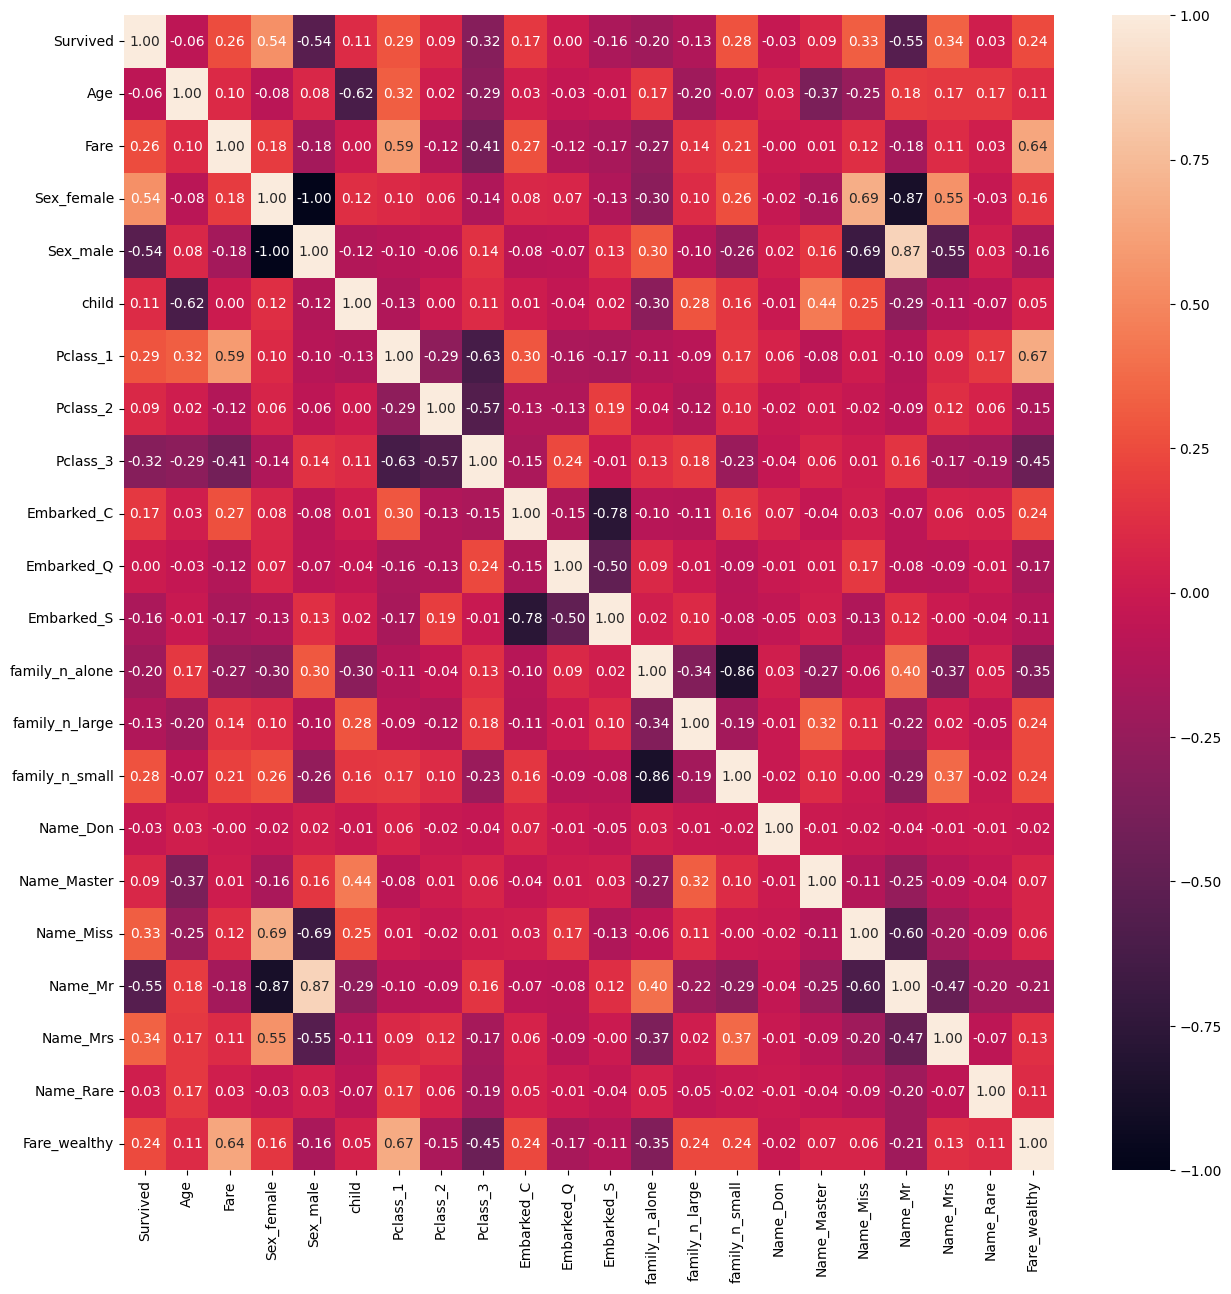

In [197]:
plt.figure(figsize=(15,15))
sns.heatmap(titanic_data.corr(),annot=True,fmt='.2f')

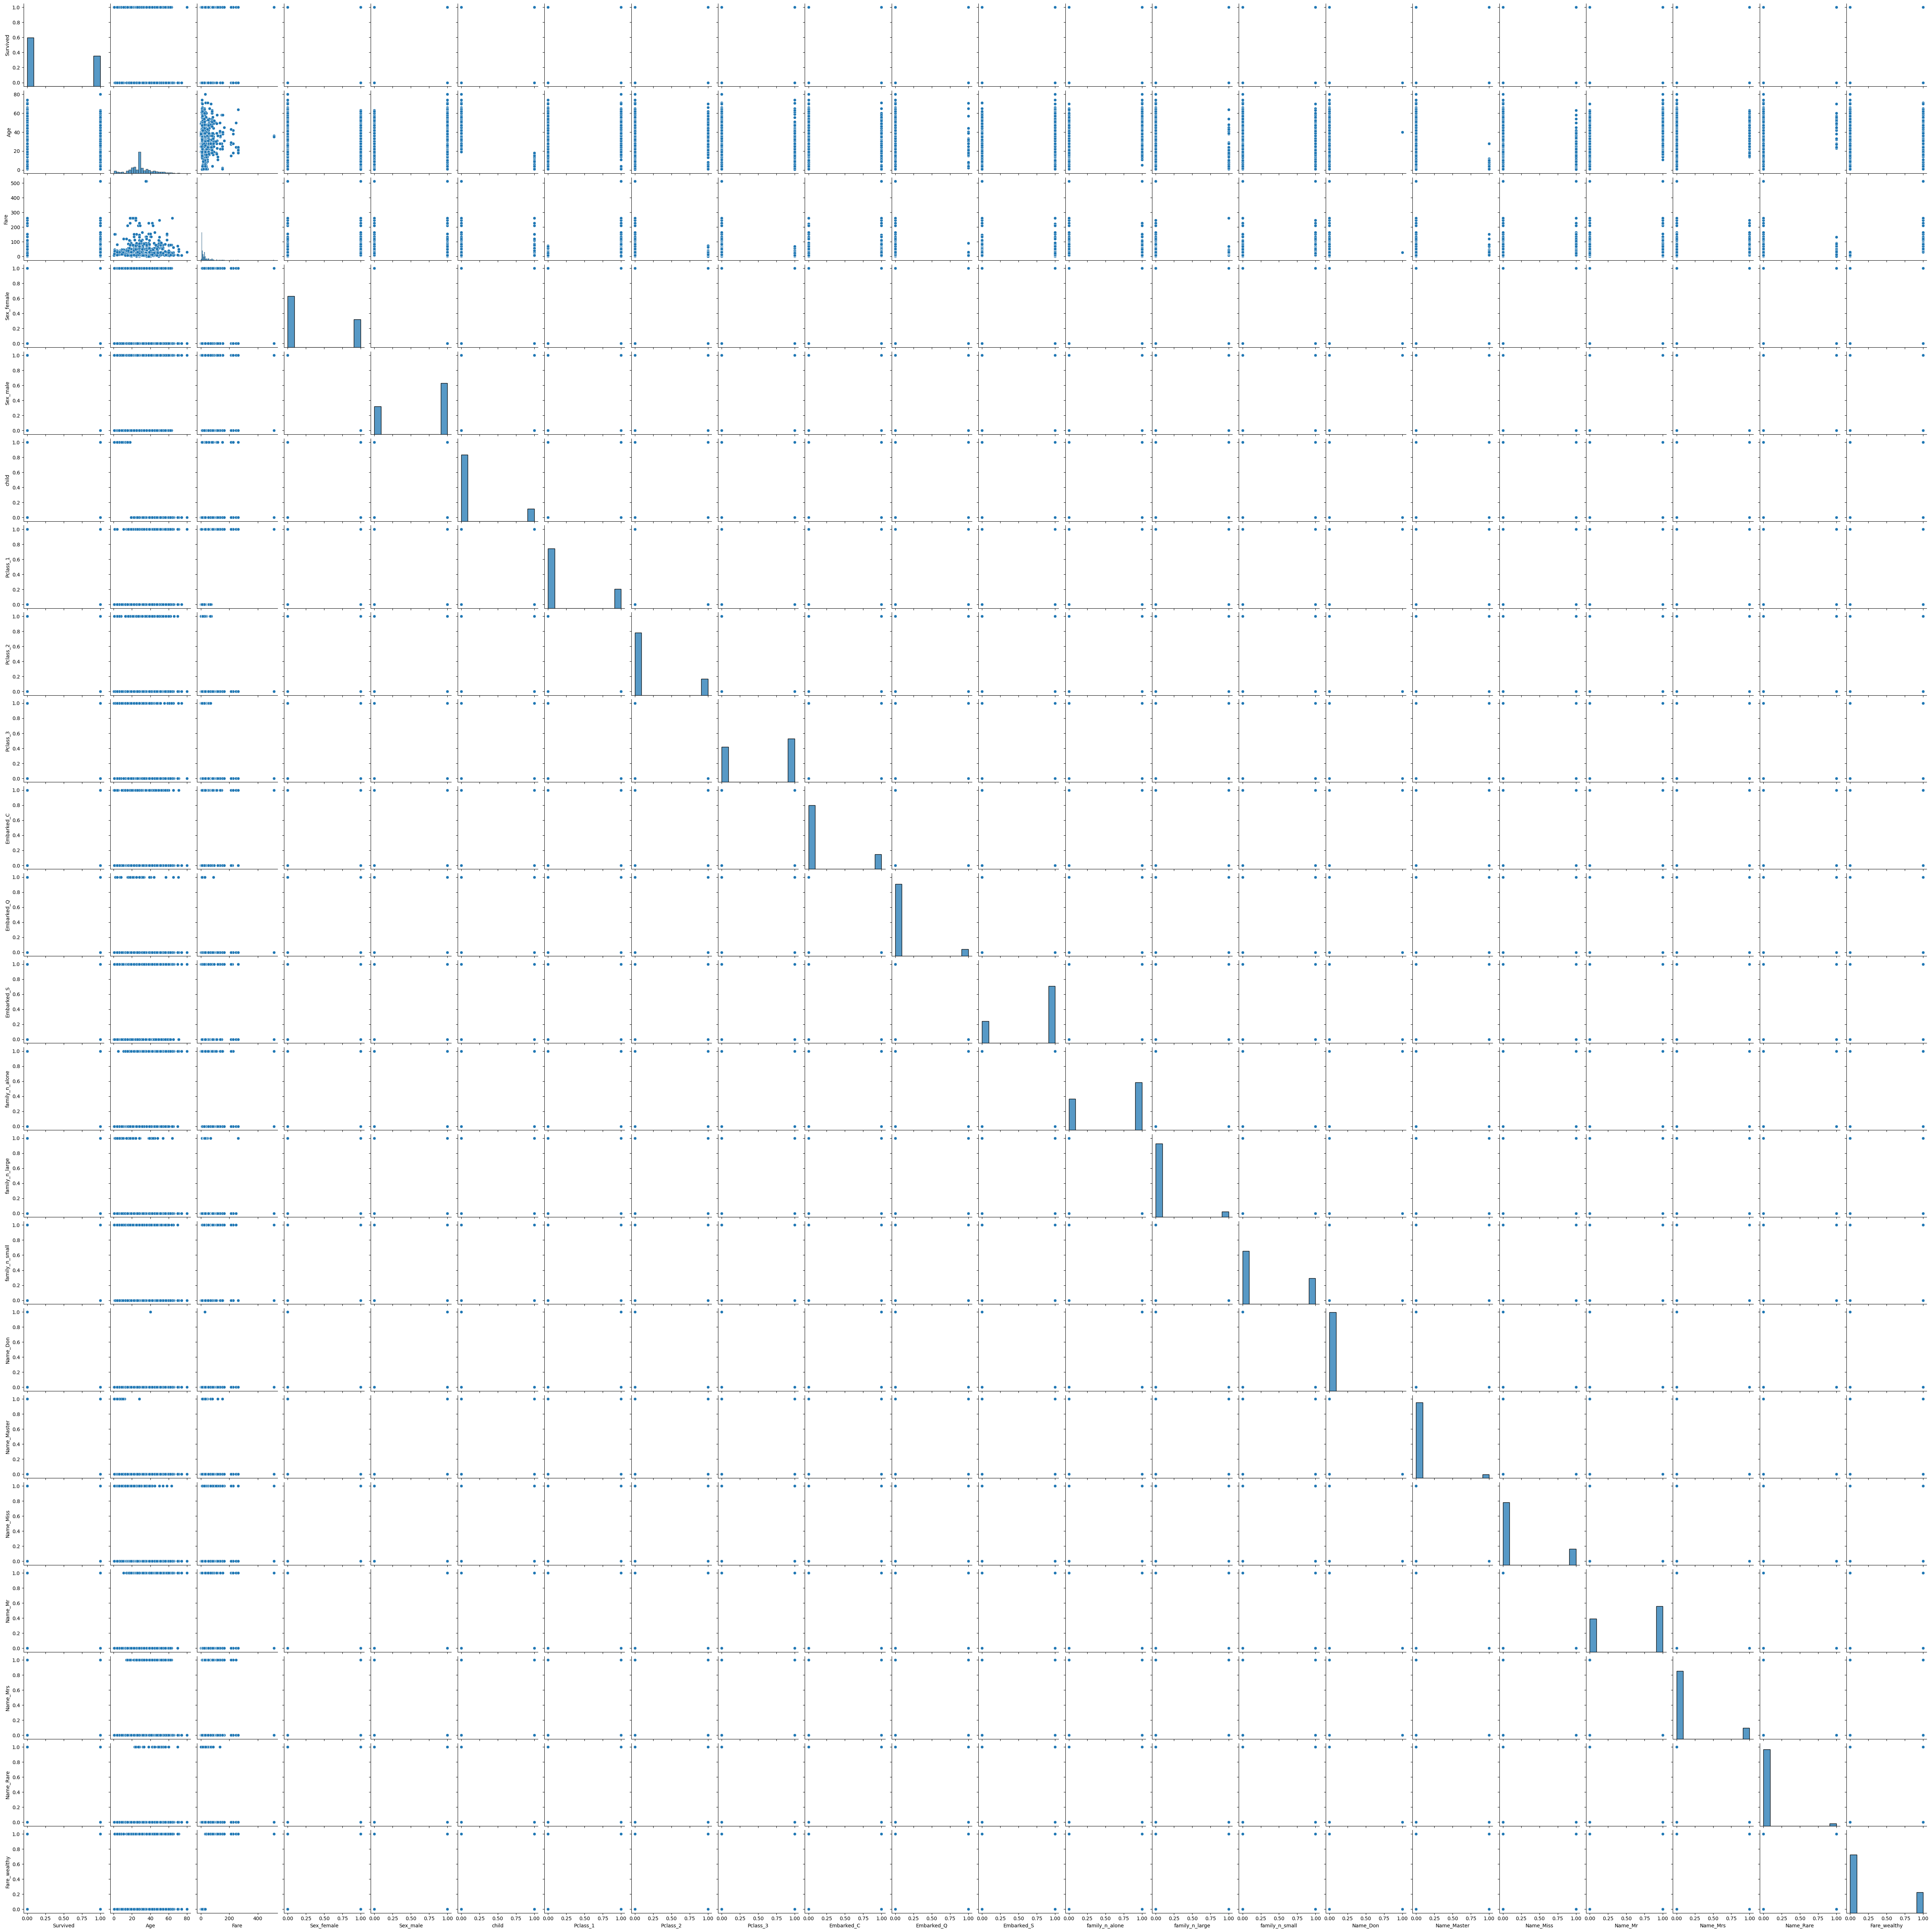

In [198]:
sns.pairplot(titanic_data)

<Axes: xlabel='Survived', ylabel='Fare_wealthy'>

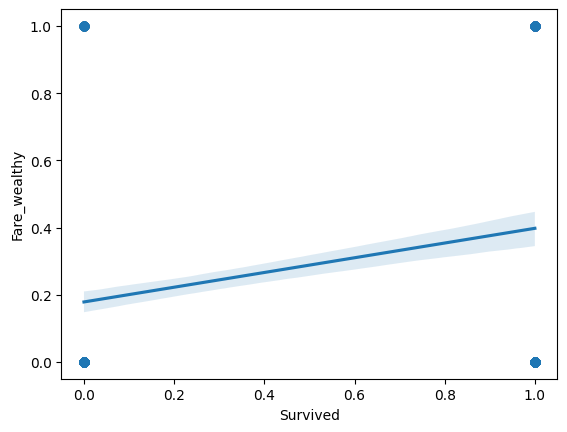

In [199]:
sns.regplot(data=titanic_data,x='Survived',y='Fare_wealthy')

<Axes: xlabel='Survived', ylabel='Fare'>

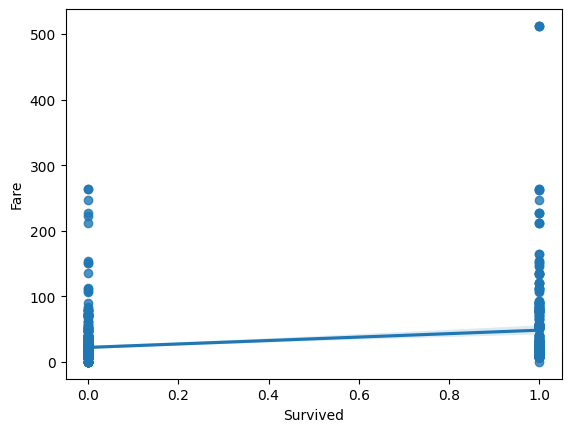

In [200]:
sns.regplot(data=titanic_data,x='Survived',y='Fare')

<Axes: xlabel='Survived', ylabel='Age'>

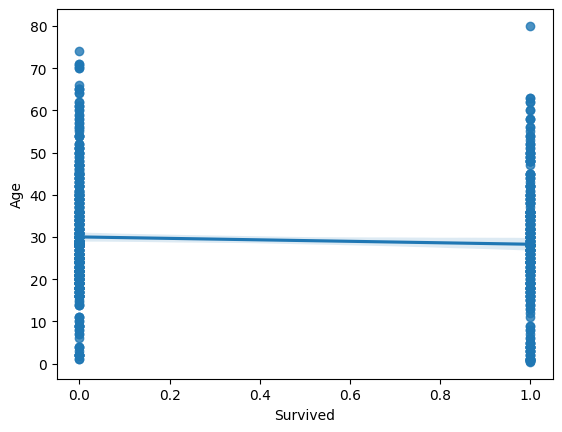

In [201]:
sns.regplot(data=titanic_data,x='Survived',y='Age')

<Axes: >

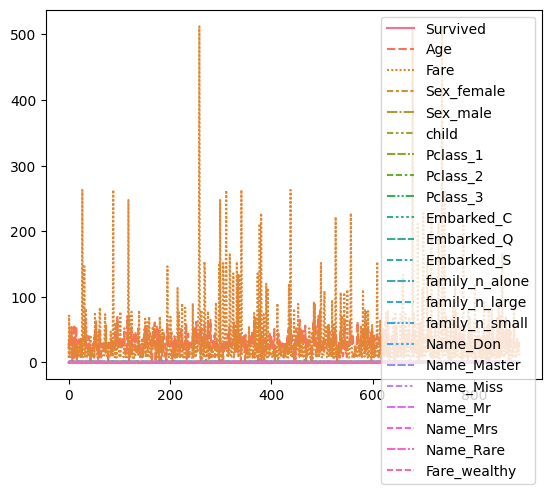

In [202]:
sns.lineplot(data=titanic_data)

<Axes: xlabel='Survived', ylabel='Fare'>

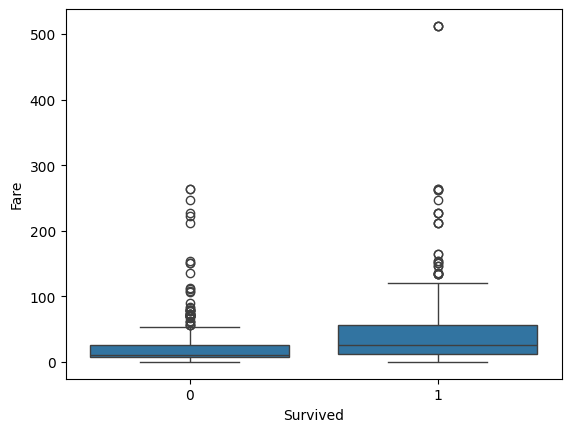

In [203]:
sns.boxplot(data=titanic_data,x='Survived',y='Fare')

In [204]:
y_data=titanic_data['Survived']
titanic_data=titanic_data.drop('Survived',axis=1)


In [205]:
titanic_data, test_data = titanic_data.align(test_data, join='left', axis=1, fill_value=0)

In [206]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score ,mean_squared_error,accuracy_score
x=titanic_data
y=y_data
xtrian,xtest,ytrian,ytest=train_test_split(x,y,test_size=0.2,random_state=42)


In [208]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
results = []
pipelines = {
    "Logistic": Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression())
    ]),

    "SVM": Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC())
    ]),

    "KNN": Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier())
    ]),

    "MLP": Pipeline([
        ('scaler', StandardScaler()),
        ('model', MLPClassifier())
    ]),


    "RandomForest": RandomForestClassifier(),

    "XGB": XGBClassifier(learning_rate=0.01,
    max_depth=3,
    random_state=42),

    "LGBM": LGBMClassifier(),

    "GradientBoosting": GradientBoostingClassifier(),

    "AdaBoost": AdaBoostClassifier(),

    "DecisionTree": DecisionTreeClassifier(max_depth=5),

    "GaussianNB": GaussianNB()
}
for name, pipe in pipelines.items():
    pipe.fit(xtrian, ytrian)
    y_pred = pipe.predict(xtest)
    acc = accuracy_score(ytest, y_pred)
    results.append([name, acc])

results_df = pd.DataFrame(results, columns=["Model", "Accuracy"])
results_df = results_df.sort_values(by="Accuracy", ascending=False)

print(results_df)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


[LightGBM] [Info] Number of positive: 268, number of negative: 444
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002620 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 207
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.376404 -> initscore=-0.504838
[LightGBM] [Info] Start training from score -0.504838
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

In [209]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score

results = []

for name, model in pipelines.items():
    model.fit(xtrian, ytrian)

    pred = model.predict(xtest)
    acc = accuracy_score(ytest, pred)

    cv_score = cross_val_score(model, x, y, cv=5).mean()

    results.append([name, acc, cv_score])

results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "CV Mean"])
results_df = results_df.sort_values(by="CV Mean", ascending=False)

print(results_df)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptro

[LightGBM] [Info] Number of positive: 268, number of negative: 444
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000145 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 207
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.376404 -> initscore=-0.504838
[LightGBM] [Info] Start training from score -0.504838
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

In [213]:
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "CV Mean"])
results_df = results_df.sort_values(by="Accuracy", ascending=False)

print(results_df)

               Model  Accuracy   CV Mean
3                MLP  0.849162  0.822692
6               LGBM  0.843575  0.827161
2                KNN  0.832402  0.804739
4       RandomForest  0.832402  0.808072
9       DecisionTree  0.826816  0.813715
1                SVM  0.821229  0.829396
0           Logistic  0.815642  0.827142
5                XGB  0.815642  0.829389
7   GradientBoosting  0.810056  0.833896
8           AdaBoost  0.804469  0.814808
10        GaussianNB  0.798883  0.790114


In [211]:
best_model_name = results_df.iloc[0]['Model']
print("Best Model:", best_model_name)

Best Model: GradientBoosting


In [212]:
best_model = pipelines[best_model_name]
best_model.fit(x, y)

predict_test = best_model.predict(test_data)

submission = pd.DataFrame({
    "PassengerId": gender_submission_data["PassengerId"],
    "Survived": predict_test
})

submission.to_csv("submission.csv", index=False)